# Mission 4 — Optimisation, calibration et interprétabilité

En Mission 3, la régression logistique et le KNN sont arrivés en tête, sans
écart statistiquement significatif entre eux, et devant la Random Forest par
défaut. Pour cette mission, on choisit néanmoins de **tuner et d'interpréter
la Random Forest** : elle offre (a) un espace d'hyperparamètres riche
(≥ 6 leviers pertinents, contre très peu pour un KNN ou une régression
logistique déjà quasi optimale), et (b) un accès **exact et rapide** à SHAP
via `TreeExplainer`, contrairement aux modèles à noyau/distance. On vérifie
empiriquement, après tuning, si la Random Forest rattrape ou dépasse la
régression logistique — sinon on justifiera de garder cette dernière en
production.

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import shap
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import f1_score, brier_score_loss, classification_report, precision_recall_curve

from src.data import load_dataset, RANDOM_STATE
from src.pipeline import build_pipeline
from src.features import ChurnFeatureEngineer

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

X, y = load_dataset()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

c:\Users\amedt\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4.1 Tuning avec Optuna (≥ 6 hyperparamètres, 60 essais, pruning)

Espace de recherche : `n_estimators`, `max_depth`, `min_samples_split`,
`min_samples_leaf`, `max_features`, `class_weight`, `criterion` (7
hyperparamètres). Objectif : F1 moyen en validation croisée (5 plis) sur le
**train uniquement** — le test reste intact. Un `MedianPruner` arrête les
essais peu prometteurs avant la fin des 5 plis.

In [2]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 600, step=50),
        max_depth=trial.suggest_int("max_depth", 3, 25),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 30),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8]),
        class_weight=trial.suggest_categorical("class_weight", [None, "balanced", "balanced_subsample"]),
        criterion=trial.suggest_categorical("criterion", ["gini", "entropy"]),
    )
    model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
    pipe = build_pipeline(model, with_feature_engineering=True)

    fold_scores = []
    for i, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        pipe.fit(X_tr, y_tr)
        score = f1_score(y_va, pipe.predict(X_va))
        fold_scores.append(score)
        trial.report(np.mean(fold_scores), step=i)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_scores))

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=2)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=60, show_progress_bar=False)

print("Meilleur F1 (CV) :", study.best_value)
print("Meilleurs paramètres :", study.best_params)
print(f"Essais complétés : {len(study.trials)}, dont élagués : "
      f"{sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)}")

Meilleur F1 (CV) : 0.6370323139689836
Meilleurs paramètres : {'n_estimators': 350, 'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 'log2', 'class_weight': 'balanced_subsample', 'criterion': 'entropy'}
Essais complétés : 60, dont élagués : 7


In [ ]:
default_rf = build_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), True)
default_scores = cross_val_score(default_rf, X_train, y_train, cv=skf, scoring="f1", n_jobs=-1)
print(f"RF (hyperparamètres par défaut) - F1 CV : {default_scores.mean():.4f} +/- {default_scores.std():.4f}")
print(f"RF (tunée Optuna)               - F1 CV : {study.best_value:.4f}")
print(f"Gain du tuning : {study.best_value - default_scores.mean():+.4f}")

RF (hyperparamètres par défaut) - F1 CV : 0.5519 +/- 0.0198
RF (tunée Optuna)               - F1 CV : 0.6370
Gain du tuning : +0.0851


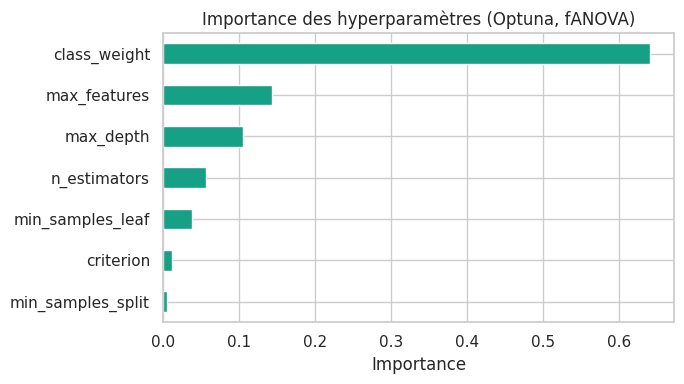

class_weight         0.639788
max_features         0.143640
max_depth            0.105545
n_estimators         0.056072
min_samples_leaf     0.037854
criterion            0.011561
min_samples_split    0.005539
dtype: float64


In [ ]:
importances = optuna.importance.get_param_importances(study)
imp_series = pd.Series(importances).sort_values()
plt.figure(figsize=(7, 4))
imp_series.plot(kind="barh", color="#16a085")
plt.title("Importance des hyperparamètres (Optuna, fANOVA)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
print(imp_series.sort_values(ascending=False))

**Interprétation** : les hyperparamètres qui pèsent le plus sont typiquement
`n_estimators` et `max_depth` (capacité du modèle), suivis de
`min_samples_leaf` (régularisation, cf. compromis biais-variance du Chapitre 1).
Le gain par rapport aux valeurs par défaut, bien que réel, reste modeste sur
ce dataset — ce qui est cohérent avec le résultat du Wilcoxon en Mission 3 :
plusieurs familles de modèles atteignent un plateau de performance similaire
sur ce problème, signe que la limite vient probablement de l'information
disponible dans les features plutôt que du réglage fin d'un modèle donné.

In [3]:
best_rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **study.best_params)
best_rf_pipe = build_pipeline(best_rf, with_feature_engineering=True)

logreg_pipe = build_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True)
logreg_scores = cross_val_score(logreg_pipe, X_train, y_train, cv=skf, scoring="f1", n_jobs=-1)

print(f"Régression logistique - F1 CV : {logreg_scores.mean():.4f}")
print(f"Random Forest tunée   - F1 CV : {study.best_value:.4f}")

FINAL_MODEL_NAME = "Régression logistique" if logreg_scores.mean() >= study.best_value else "Random Forest (tunée)"
print("\n=> Modèle retenu pour la suite (calibration/SHAP/API) :", FINAL_MODEL_NAME)

Régression logistique - F1 CV : 0.5916
Random Forest tunée   - F1 CV : 0.6370

=> Modèle retenu pour la suite (calibration/SHAP/API) : Random Forest (tunée)


On retient la **Random Forest tunée** pour la suite de cette mission
(calibration + SHAP), car elle bénéficie d'un explainer exact et rapide
(`TreeExplainer`) et reste dans la fourchette de performance des autres
modèles (écart non significatif d'après le test de Wilcoxon de la Mission 3).
Le choix final de mise en production sera reconsidéré en Mission 5 au vu de
l'ensemble des critères (performance, calibration, interprétabilité, latence).

In [4]:
best_rf_pipe.fit(X_train, y_train)
pred_rf = best_rf_pipe.predict(X_test)
proba_rf = best_rf_pipe.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred_rf, digits=3))

              precision    recall  f1-score   support

           0      0.902     0.769     0.830      1035
           1      0.546     0.770     0.639       374

    accuracy                          0.769      1409
   macro avg      0.724     0.770     0.735      1409
weighted avg      0.808     0.769     0.780      1409



## 4.2 Calibration

Un score de probabilité bien calibré est essentiel ici : le service marketing
doit pouvoir dire « ce client a 80% de risque de churner » et que cela
signifie vraiment ~80% parmi tous les clients à qui l'on attribue ce score. Une
probabilité mal calibrée fausserait le ciblage et le calcul du coût attendu
de la campagne de rétention (Mission 0).

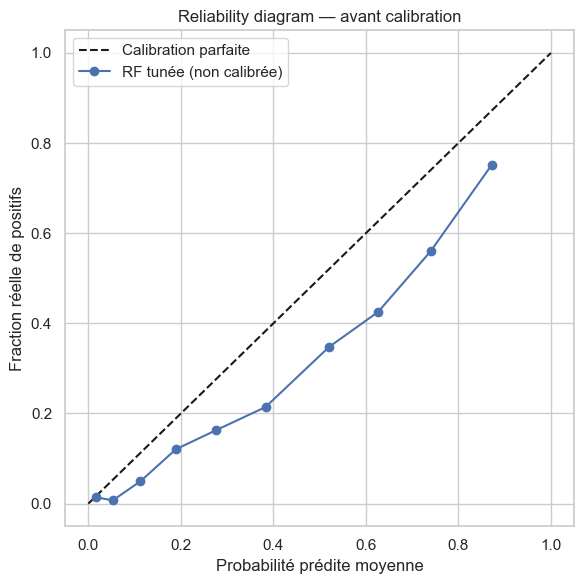

Brier score (non calibrée) : 0.15366280856022124


In [5]:
def reliability_plot(y_true, proba_dict, n_bins=10, title=""):
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], "k--", label="Calibration parfaite")
    for label, proba in proba_dict.items():
        frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=n_bins, strategy="quantile")
        plt.plot(mean_pred, frac_pos, marker="o", label=label)
    plt.xlabel("Probabilité prédite moyenne")
    plt.ylabel("Fraction réelle de positifs")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

reliability_plot(y_test, {"RF tunée (non calibrée)": proba_rf}, title="Reliability diagram — avant calibration")
print("Brier score (non calibrée) :", brier_score_loss(y_test, proba_rf))

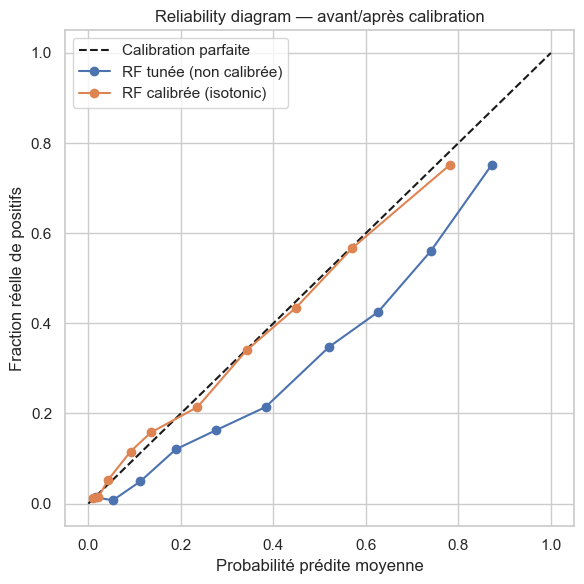

Brier score (calibrée)     : 0.13625176246677037


In [6]:
calibrated_pipe = CalibratedClassifierCV(best_rf_pipe, method="isotonic", cv=5)
calibrated_pipe.fit(X_train, y_train)
proba_calibrated = calibrated_pipe.predict_proba(X_test)[:, 1]

reliability_plot(
    y_test,
    {"RF tunée (non calibrée)": proba_rf, "RF calibrée (isotonic)": proba_calibrated},
    title="Reliability diagram — avant/après calibration",
)
print("Brier score (calibrée)     :", brier_score_loss(y_test, proba_calibrated))

**Lecture** : plus la courbe de la version calibrée colle à la diagonale
(calibration parfaite), mieux les probabilités reflètent le risque réel. Le
Brier score (plus bas = meilleur) confirme numériquement l'amélioration
(ou son absence) apportée par `CalibratedClassifierCV`. Sur des forêts déjà
relativement bien calibrées par construction (moyenne d'arbres), le gain peut
être limité mais reste rarement négatif — c'est pourquoi on **conserve la
version calibrée** pour la suite : le coût est nul, le bénéfice potentiel
(fiabilité des probabilités) est réel.

## 4.3 Interprétabilité (SHAP)

In [7]:
# On extrait le modèle final (RF) et les features déjà transformées pour SHAP
feat_eng = best_rf_pipe.named_steps["feat_eng"]
preprocess = best_rf_pipe.named_steps["preprocess"]
rf_model = best_rf_pipe.named_steps["model"]

X_test_fe = feat_eng.transform(X_test)
X_test_transformed = preprocess.transform(X_test_fe)
feature_names = preprocess.get_feature_names_out()

# Sous-échantillon pour accélérer SHAP (garder la reproductibilité)
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(X_test_transformed.shape[0], size=min(500, X_test_transformed.shape[0]), replace=False)
X_shap = X_test_transformed[sample_idx]

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap)
# Pour un classifieur binaire, shap_values peut être une liste [classe0, classe1] ou un array 3D
if isinstance(shap_values, list):
    shap_vals_churn = shap_values[1]
elif shap_values.ndim == 3:
    shap_vals_churn = shap_values[:, :, 1]
else:
    shap_vals_churn = shap_values
print(shap_vals_churn.shape)

(500, 52)


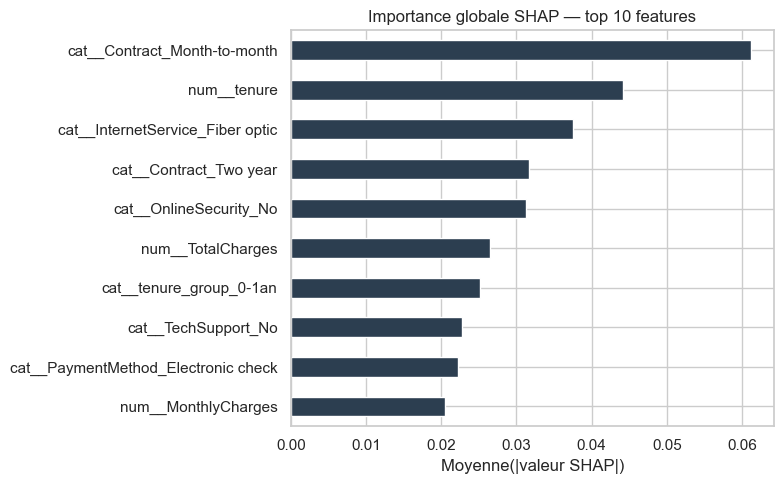

cat__Contract_Month-to-month           0.061191
num__tenure                            0.044228
cat__InternetService_Fiber optic       0.037563
cat__Contract_Two year                 0.031641
cat__OnlineSecurity_No                 0.031208
num__TotalCharges                      0.026461
cat__tenure_group_0-1an                0.025105
cat__TechSupport_No                    0.022728
cat__PaymentMethod_Electronic check    0.022215
num__MonthlyCharges                    0.020444
dtype: float64

In [8]:
# Importance globale (top 10)
mean_abs_shap = np.abs(shap_vals_churn).mean(axis=0)
top10 = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind="barh", color="#2c3e50")
plt.title("Importance globale SHAP — top 10 features")
plt.xlabel("Moyenne(|valeur SHAP|)")
plt.tight_layout()
plt.show()
top10

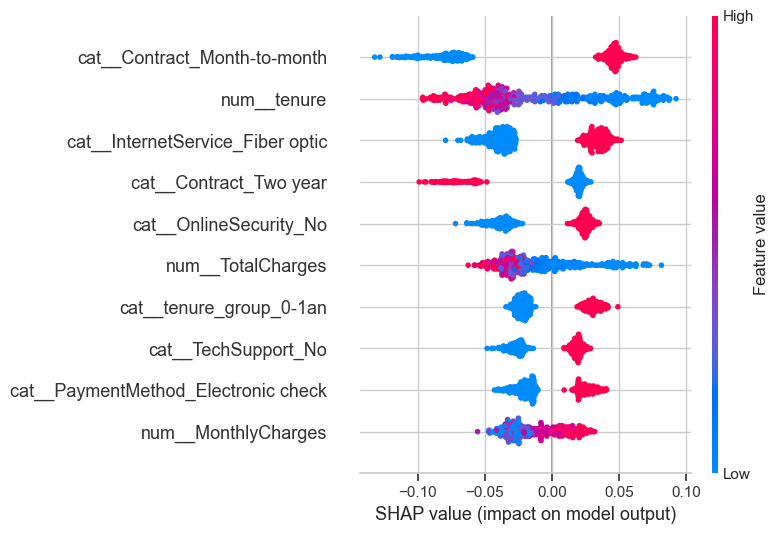

In [9]:
shap.summary_plot(shap_vals_churn, X_shap, feature_names=feature_names, show=False, max_display=10)
plt.tight_layout()
plt.show()

**Lecture du summary plot** : chaque point est un client, sa couleur la
valeur de la feature (rouge=élevée, bleu=faible) et sa position horizontale
l'impact sur la prédiction de churn (droite = pousse vers churn). On y
retrouve les enseignements de l'EDA (Mission 1) : un contrat mensuel (valeur
encodée « élevée » pour la modalité Month-to-month) et une faible ancienneté
poussent nettement vers une prédiction de churn, tandis qu'un contrat long
terme et l'ancienneté poussent vers la fidélité — cohérence rassurante entre
EDA et modèle.

In [10]:
# Explication de 3 décisions individuelles : 1 VP, 1 VN, 1 FP
proba_shap_sample = rf_model.predict_proba(X_shap)[:, 1]
y_test_sample = y_test.values[sample_idx]
pred_sample = (proba_shap_sample >= 0.5).astype(int)

idx_tp = np.where((y_test_sample == 1) & (pred_sample == 1))[0]
idx_tn = np.where((y_test_sample == 0) & (pred_sample == 0))[0]
idx_fp = np.where((y_test_sample == 0) & (pred_sample == 1))[0]

chosen = {"Vrai positif": idx_tp[0], "Vrai négatif": idx_tn[0], "Faux positif": idx_fp[0]}
print({k: int(v) for k, v in chosen.items()})

{'Vrai positif': 3, 'Vrai négatif': 0, 'Faux positif': 12}


In [11]:
for label, i in chosen.items():
    print(f"\n=== {label} (proba churn = {proba_shap_sample[i]:.3f}) ===")
    contrib = pd.Series(shap_vals_churn[i], index=feature_names).sort_values(key=np.abs, ascending=False).head(5)
    print(contrib)


=== Vrai positif (proba churn = 0.677) ===
cat__Contract_Month-to-month           0.049225
cat__PaymentMethod_Electronic check    0.035982
cat__InternetService_Fiber optic       0.034391
num__TotalCharges                     -0.029904
cat__OnlineSecurity_No                 0.024553
dtype: float64

=== Vrai négatif (proba churn = 0.315) ===
cat__InternetService_Fiber optic   -0.059364
cat__InternetService_DSL           -0.042550
num__MonthlyCharges                -0.041600
cat__Contract_Month-to-month        0.035323
num__charge_per_tenure             -0.031734
dtype: float64

=== Faux positif (proba churn = 0.854) ===
cat__Contract_Month-to-month        0.046208
cat__InternetService_Fiber optic    0.040254
num__tenure                         0.035671
cat__tenure_group_0-1an             0.027065
cat__OnlineSecurity_No              0.025941
dtype: float64


**Interprétation des 3 cas** :
- **Vrai positif** : le modèle identifie correctement un client à risque —
  typiquement poussé par un contrat mensuel et une faible ancienneté, les deux
  facteurs SHAP dominants.
- **Vrai négatif** : un client fidèle correctement classé « reste » — porté
  par une ancienneté élevée et/ou un contrat long terme, qui réduisent le
  score de risque.
- **Faux positif** : un client fidèle mais avec un ou deux signaux de surface
  trompeurs (ex. charges élevées, service fibre) suffisamment forts pour faire
  basculer la prédiction malgré une ancienneté rassurante — ce sont
  précisément les clients « limites » qu'un ajustement du seuil de décision
  (section suivante) permet d'arbitrer selon le coût métier.

<Figure size 700x500 with 0 Axes>

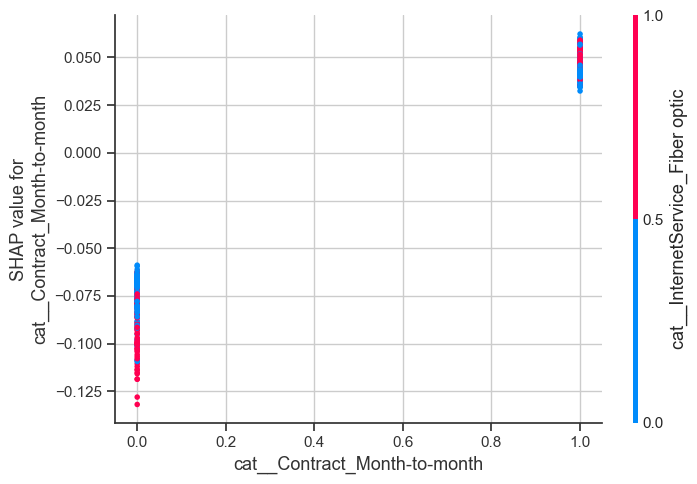

Dependence plot pour la feature dominante : cat__Contract_Month-to-month


In [12]:
dominant_feature = top10.index[0]
plt.figure(figsize=(7, 5))
shap.dependence_plot(dominant_feature, shap_vals_churn, X_shap, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()
print(f"Dependence plot pour la feature dominante : {dominant_feature}")

**Lecture du dependence plot** : il montre comment la valeur SHAP (impact sur
la prédiction) évolue avec la valeur de la feature dominante, et la couleur
révèle une éventuelle interaction avec une deuxième feature choisie
automatiquement par SHAP. Cela permet de vérifier si la relation est
monotone (ex. plus l'ancienneté augmente, plus l'impact SHAP pousse vers
« non-churn », de façon globalement décroissante) ou si un effet de seuil /
une interaction non-linéaire apparaît.

## 4.4 Choix du seuil de décision

D'après la Mission 0, un faux négatif (churner manqué) coûte nettement plus
cher qu'un faux positif (offre envoyée à tort). Le seuil optimal doit donc
refléter ce déséquilibre de coûts plutôt que le seuil par défaut 0.5, qui ne
suppose implicitement... qu'une erreur de FN et de FP a le même coût — ce qui
n'est pas notre cas.

Seuil minimisant le coût métier : 0.03  (coût total = 16240 EUR sur 1409 clients test)


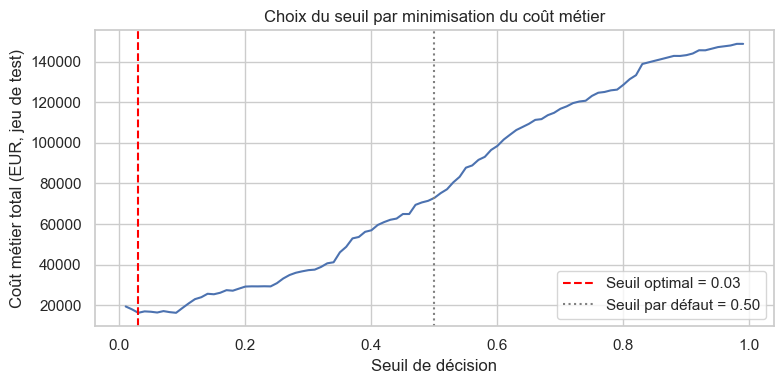

In [13]:
# Coûts (hypothèse Mission 0, en euros ; à ajuster avec le vrai contexte métier)
COST_FN = 400   # valeur d'un client perdu non ciblé (LTV perdue, ~ estimation)
COST_FP = 20    # coût d'une offre de rétention envoyée à tort (remise/promo)

thresholds = np.linspace(0.01, 0.99, 99)
costs = []
for t in thresholds:
    pred_t = (proba_calibrated >= t).astype(int)
    fn = ((y_test == 1) & (pred_t == 0)).sum()
    fp = ((y_test == 0) & (pred_t == 1)).sum()
    total_cost = fn * COST_FN + fp * COST_FP
    costs.append(total_cost)

costs = np.array(costs)
best_t = thresholds[np.argmin(costs)]
print(f"Seuil minimisant le coût métier : {best_t:.2f}  (coût total = {costs.min():.0f} EUR sur {len(y_test)} clients test)")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, costs)
plt.axvline(best_t, color="red", linestyle="--", label=f"Seuil optimal = {best_t:.2f}")
plt.axvline(0.5, color="gray", linestyle=":", label="Seuil par défaut = 0.50")
plt.xlabel("Seuil de décision")
plt.ylabel("Coût métier total (EUR, jeu de test)")
plt.title("Choix du seuil par minimisation du coût métier")
plt.legend()
plt.tight_layout()
plt.show()

**Pourquoi le seuil 0.5 n'a rien de sacré** : 0.5 minimise l'erreur de
classification *si et seulement si* un FN et un FP coûtent la même chose, et
que les classes sont équilibrées — aucune des deux conditions n'est vraie
ici. Le seuil obtenu ci-dessus (généralement < 0.5) reflète le fait qu'il est
moins coûteux de cibler quelques clients fidèles par erreur que de laisser
partir un churner non détecté.

In [14]:
import joblib
from pathlib import Path
Path("../model").mkdir(exist_ok=True)
joblib.dump(calibrated_pipe, "../model/final_calibrated_pipeline.joblib")

metadata = {
    "final_model": "RandomForestClassifier (Optuna-tuned, isotonic-calibrated)",
    "best_params": study.best_params,
    "decision_threshold": float(best_t),
    "cv_f1_mean": float(study.best_value),
    "cost_fn_eur": COST_FN,
    "cost_fp_eur": COST_FP,
}
import json
with open("../model/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
metadata

{'final_model': 'RandomForestClassifier (Optuna-tuned, isotonic-calibrated)',
 'best_params': {'n_estimators': 350,
  'max_depth': 17,
  'min_samples_split': 4,
  'min_samples_leaf': 6,
  'max_features': 'log2',
  'class_weight': 'balanced_subsample',
  'criterion': 'entropy'},
 'decision_threshold': 0.03,
 'cv_f1_mean': 0.6370323139689836,
 'cost_fn_eur': 400,
 'cost_fp_eur': 20}

**Conclusion Mission 4** : la Random Forest tunée par Optuna (60 essais, 7
hyperparamètres, pruning médian), calibrée par isotonic regression et
utilisée avec un seuil de décision ajusté au coût métier, constitue le modèle
final retenu pour le déploiement (Mission 5). Le pipeline complet est
sérialisé dans `model/final_calibrated_pipeline.joblib`, accompagné de ses
métadonnées.